In [1]:
import Pkg
Pkg.add("Kinbiont");
Pkg.add("SymbolicRegression");
Pkg.add("Plots");
Pkg.add("CSV");
Pkg.add("Tables");
using Kinbiont;
using SymbolicRegression;
using Plots;
using Tables;
using CSV;

   Resolving package versions...
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks\Project.toml`
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks\Manifest.toml`
   Resolving package versions...
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks\Project.toml`
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks\Manifest.toml`
   Resolving package versions...
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks\Project.toml`
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks\Manifest.toml`
   Resolving package versions...
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks\Project.toml`
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks

Setting the path to the data and the annotation file

In [3]:
path_to_calibration = "../Automatic_law_detection/Dose_response_sym_regression/Data/cal_curve_avg.csv";
path_to_data =        "../Automatic_law_detection/Dose_response_sym_regression//Data/data_H.csv";
path_to_annotation =  "../Automatic_law_detection/Dose_response_sym_regression//Data/annotation_short.csv";


We set the parameters of the fitting for Kinbiont

In [4]:
model1 = "HPM_exp";

lb_param1 = [0.00001, 0.000001];
ub_param1 =[3.5,       10.5];
param_guess1 =[0.1, 0.01];
    
model2 = "logistic";

lb_param2 = [0.00001, 0.000001];
ub_param2 =[4.5,       5.5    ];
param_guess2 =[0.1, 1.01];
    
# creating the array of models, param_guess, lb_param, ub_param for Kinbiont

list_of_models = [model1,model2];
list_guess=  [param_guess1,param_guess2];
list_lb=  [lb_param1,lb_param2];
list_ub=  [ub_param1,ub_param2];

Calling the segmentation fit function, we fix the number of cp to 1 to separate the growth rate from the stationary phase


In [ ]:
# calling the segmentation function, we fix the number of cp to 1 to separate the growth rate from the stationary phase

Kinbiont_seg_analysis =  segmentation_ODE_file(
  "fit_antibio_response", #label of the experiment
  path_to_data, # path to the folder to analyze
  list_of_models, # ode model to use 
  list_guess, #  param
  1;
  path_to_annotation=path_to_annotation,# path to the annotation of the wells
  detect_number_cpd=false,
  fixed_cpd=false,
  calibration_OD_curve=path_to_calibration,
  multiple_scattering_correction=true, # if true uses the given calibration curve to fix the data
  type_of_curve="deriv",
  pt_smooth_derivative= 12,
  verbose = true,
  write_res =false,
  type_of_smoothing="rolling_avg",
  win_size=12, # 
  smoothing =true,
  lb_param_array=list_lb, # lower bound param
  ub_param_array=list_ub, # upper bound param
  maxiters = 200000
);

Prepare the results matrix, by considering only the fist segment and later only the wells that are drugfree or with chl.

In [6]:
index_first_segment = findall(Kinbiont_seg_analysis[2][9,:].==1);

results_matrix =hcat(Kinbiont_seg_analysis[2][:,1] ,Kinbiont_seg_analysis[2][:,index_first_segment]);


We prepare the feature matrix importing it from a file

In [10]:
path_to_annotation_full=  "../Automatic_law_detection/Dose_response_sym_regression/Data/annotation_full.csv";
annotation_test = CSV.read(path_to_annotation_full,header =false,Tables.matrix);


index_not_used_wells  = findall(annotation_test[:,2].== "X" .|| annotation_test[:,2].== "b");
non_blank_wells = setdiff(1:1:length(annotation_test[:,1]),index_not_used_wells);
annotation_test_no_blank= annotation_test[non_blank_wells,:];
index_df_wells  =  annotation_test_no_blank[findall( annotation_test_no_blank[:,5].== "DF" ),1];
index_chl_wells  =  annotation_test_no_blank[findall( annotation_test_no_blank[:,5].== "Chloramphenicol" ),1];


index_to_use_df = [ findall(  index_df_wells[i,1] .==annotation_test_no_blank[:,1] ) for i in 1:length(index_df_wells[:,1])] ;
index_to_use_df = reduce(vcat,index_to_use_df);



index_to_use_chl =   [ findall( index_chl_wells[i,1] .== annotation_test_no_blank[:,1] ) for i in 1:length(index_chl_wells[:,1])] ;
index_to_use_chl =  reduce(vcat,index_to_use_chl);
index_to_use_chl =  vcat(index_to_use_df,index_to_use_chl);



feature_matrix_chl =hcat(annotation_test_no_blank[index_to_use_chl,1], annotation_test_no_blank[index_to_use_chl,6]);


# selectin index of results matrix to use for  chl

index_to_use_chl_results = [ findall(  feature_matrix_chl[i,1] .== results_matrix[2,:]) for i in 1:length( feature_matrix_chl[:,1])] ;
index_to_use_chl_results =  reduce(vcat,index_to_use_chl_results);



results_matrix_chl =hcat(results_matrix[:,1] ,results_matrix[:,index_to_use_chl_results]);



9×25 Matrix{Any}:
 "label_exp"   "fit_antibio_response"  …   "fit_antibio_response"
 "well"        "A3"                        "F4"
 "model"       "HPM_exp"                   "logistic"
 "param_1"    0.599654                    0.208821
 "param_2"    0.218035                    0.588168
 "th_gr"      0.59838                  …  0.205438
 "em_gr"      0.809611                    0.334309
 "loss"       0.000276511                 9.97322e-5
 "segment"    1                           1

The feature matrix is the following:

In [8]:
feature_matrix_chl

24×2 Matrix{Any}:
 "A3"   0
 "A4"   0
 "A5"   0
 "A6"   0
 "B1"   2
 "B2"   2
 "B3"   2
 "B4"   2
 "C1"   4
 "C2"   4
 ⋮              
 "D4"   8
 "E1"  12
 "E2"  12
 "E3"  12
 "E4"  12
 "F1"  16
 "F2"  16
 "F3"  16
 "F4"  16

The results matrix

In [9]:
results_matrix_chl

9×25 Matrix{Any}:
 "label_exp"   "fit_antibio_response"  …   "fit_antibio_response"
 "well"        "A3"                        "F4"
 "model"       "HPM_exp"                   "logistic"
 "param_1"    0.599654                    0.208821
 "param_2"    0.218035                    0.588168
 "th_gr"      0.59838                  …  0.205438
 "em_gr"      0.809611                    0.334309
 "loss"       0.000276511                 9.97322e-5
 "segment"    1                           1

We plot the data we are going to use

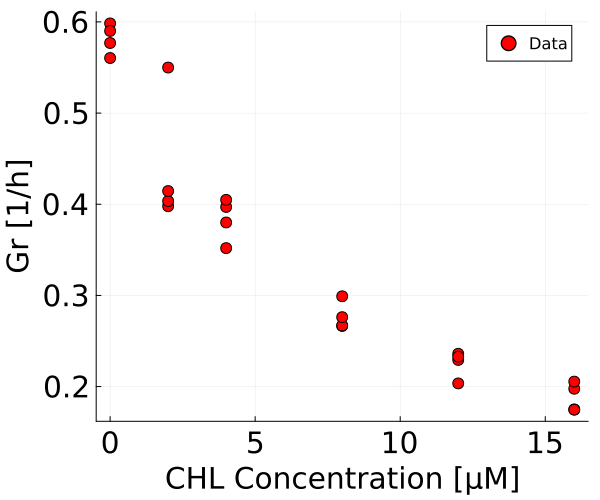

In [17]:
display(scatter(feature_matrix_chl[:,2],results_matrix_chl[6,2:end],xlabel= "CHL Concentration [μM]",ylabel = "Gr [1/h]",label=[ "Data" nothing],size = (600,500),markersize = 6,color= :red,tickfontsize = 20,labelfontsize = 20,legendfontsize =11,legend=:topright))


We set the symbolic regression options

In [12]:
options = SymbolicRegression.Options(;
 binary_operators=[+,  /, * , -]  ,
 unary_operators=[],
 constraints=nothing,
 elementwise_loss=nothing,
 loss_function=nothing,
 tournament_selection_n=12, #1 sampled from every tournament_selection_n per mutation
 tournament_selection_p=0.86,
 topn=12, #samples to return per population
 complexity_of_operators=nothing,
 complexity_of_constants=nothing,
 complexity_of_variables=nothing,
 parsimony=0.05,
 dimensional_constraint_penalty=nothing,
 alpha=0.100000,
 maxsize=10,
 seed =1234,
 maxdepth=nothing,
 

);

Regression on growth rate vs chl conc

In [13]:
gr_chl = downstream_symbolic_regression(results_matrix_chl,
feature_matrix_chl,
   6;
 #   options = options,
);

arning: You are using multithreading mode, but only one thread is available. Try starting julia with `--threads=auto`.



























































































































































































Evolving for 100 iterations... 100%|█████████████████████| Time: 0:00:13


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.920e-02  3.604e+01  y = 0.34949
5           9.009e-04  7.648e-01  y = 4.353 / (x₁ + 7.5597)
7           8.914e-04  5.339e-03  y = (3.7418 / (x₁ + 6.7599)) + 0.025196
9           8.914e-04  2.189e-13  y = (1.1446 / (2.0678 - (x₁ * -0.30589))) + 0.025196
11          8.914e-04  2.637e-14  y = (-0.51139 / (-0.64856 - ((x₁ + 2.0145) * 0.13667))) - ...
                                      -0.025196
13          8.568e-04  1.979e-02  y = (0.84637 - (0.010674 / (2.3067 - x₁))) / (1.4483 - (x₁...
                                       * -0.19509))
15          8.519e-04  2.844e-03  y = ((-0.011691 / (3.0556 - x₁)) + 0.03025) + (1.1461 / (2...
                                      .065 - (x₁ * -0.32501)))
19          8.519e-04  9.719e-06  y = ((1.1454 - (0.033683 / (2.9487 - ((x₁ * -0.057719) + x...
                                      ₁))))

┌ Info: Final population:
└ @ SymbolicRegression C:\Users\fabri\.julia\packages\SymbolicRegression\5p5kQ\src\SymbolicRegression.jl:1149
┌ Info: Results saved to:
└ @ SymbolicRegression C:\Users\fabri\.julia\packages\SymbolicRegression\5p5kQ\src\SymbolicRegression.jl:1172


We display the hall of fame

In [14]:
gr_chl[1]

11-element Vector{Expression{Float64, Node{Float64}, @NamedTuple{operators::OperatorEnum{Tuple{typeof(+), typeof(-), typeof(/), typeof(*)}, Tuple{}}, variable_names::Vector{String}}}}:
 0.3494927273450572
 4.3529988110008055 / (x1 + 7.559665517679545)
 (3.741757055966917 / (x1 + 6.759927124440454)) + 0.025196378710819124
 (1.1445791051891139 / (2.0678174043936086 - (x1 * -0.30589329110464614))) + 0.02519628659862687
 (-0.5113919652142815 / (-0.6485616544778482 - ((x1 + 2.0145263072534725) * 0.13667149625831954))) - -0.02519625675596353
 (0.8463685032086298 - (0.010674407964438712 / (2.3067366715054134 - x1))) / (1.4482698807935674 - (x1 * -0.1950864845454925))
 ((-0.01169132067374303 / (3.055603512627919 - x1)) + 0.03024986225816794) + (1.146146774837571 / (2.06496694459722 - (x1 * -0.3250110347230408)))
 ((1.1454030228587007 - (0.03368278375811053 / (2.9486588779963787 - ((x1 * -0.05771927378503656) + x1)))) / (2.064918746748144 - (x1 * -0.32850069054736414))) + 0.03227153831670961
 (

We can plot the resulting function using Kinbiont plotting function outputs:

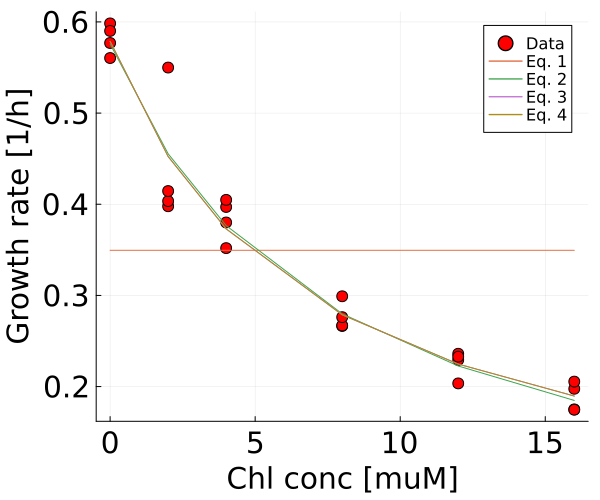

In [18]:
plot!(feature_matrix_chl[:,2],gr_chl[3][:,1], label = "Eq. 1", xlabel = "Chl conc [muM]", ylabel = "Growth rate [1/h]")
plot!(feature_matrix_chl[:,2],gr_chl[3][:,2], label = "Eq. 2",  xlabel = "Chl conc [muM]", ylabel = "Growth rate [1/h]")
plot!(feature_matrix_chl[:,2],gr_chl[3][:,3], label = "Eq. 3",  xlabel = "Chl conc [muM]", ylabel = "Growth rate [1/h]")
display(plot!(feature_matrix_chl[:,2],gr_chl[3][:,4], label = "Eq. 4",  xlabel = "Chl conc [muM]", ylabel = "Growth rate [1/h]"))
